In [6]:
from datasets import load_dataset
import numpy as np
import pandas as pd


o:\enset\hello\Agentic AI\tps\Use-Case-Sentiment-Analysis\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
ds = load_dataset('imdb')

In [8]:
ds

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [9]:
train_df = ds['train'].to_pandas();

In [10]:
train_df.sample(5)

,text,label
11757,"As gently as I can, I sincerely believe this m...",0
11864,This insipid mini operetta featuring a Eddy-Mc...,0
19000,If you r in mood for fun...and want to just re...,1
10974,Marvin(Rob Schneider)does not have the ingredi...,0
8623,This is the first non-zombie subgenre review i...,0


In [11]:
train_df['label'].value_counts()

label
0    12500
1    12500
Name: count, dtype: int64

In [12]:
train_df['sentiment'] = np.where(train_df['label'] == 1, 'positive', 'negative')

In [13]:
train_df.sentiment.value_counts()

sentiment
negative    12500
positive    12500
Name: count, dtype: int64

<Axes: >

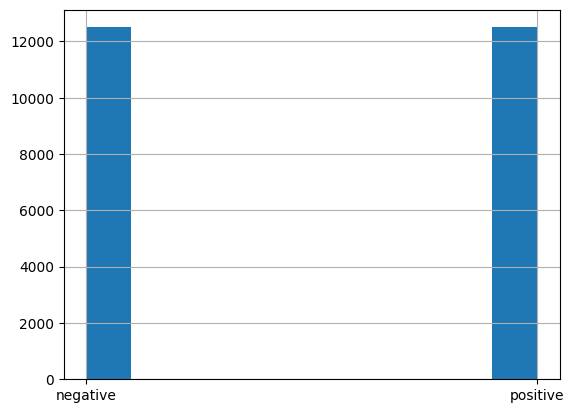

In [14]:
train_df.sentiment.hist()

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
examples_df , gold_examples_df = train_test_split(train_df, test_size=0.2, random_state=123)

In [17]:
examples_df.shape, gold_examples_df.shape

((20000, 3), (5000, 3))

In [18]:
columns = ['text', 'sentiment']
gold_examples = (gold_examples_df[columns]
                 .sample(10,random_state=34)
                 .to_json(orient='records')
                 )


In [19]:
import json

In [20]:
json.loads(gold_examples)[0]

{'text': '"A Guy Thing" may not be a classic, but it sure is a good, funny comedy. The plot focuses on Paul (Jason Lee), who wakes up the morning after his bachelor party with no memory and Becky (Julia Stiles) lying naked in his bed. Before he can figure out what happened, he rushes Becky out of his apartment because his fiance Karen (Selma Blair) is coming. After that, as you could imagine, chaos ensues.<br /><br />Almost every single scene in "A Guy Thing" delivers loud laughs. The funniest moments come from when Paul imagines what could happen if he tells Karen. Selma Blair is a truly talented comedian, and the worst thing about this film is that she goes underused. Although, she turns out to be more funny than Stiles\' character, who actually isn\'t that interesting. Of course, not every comedy is perfect.<br /><br />As I said, "A Guy Thing" is no classic, but it\'s not bad either, 7/10.',
 'sentiment': 'positive'}

In [21]:
user_prompt_template = """```{movie_review}```""" 

In [22]:
zero_shot_prompt_system = """
Classify the sentiment of movie reviews presented in the input as either positive or negative.
Movie reviews will be delimited by triple backticks ``` in the input
Answer only as 'positive' or 'negative'
Do not explain your answer, just give the label.
"""

In [23]:
zero_shot_prompt = [{"role": 'system', "content": zero_shot_prompt_system}] 

In [24]:
few_shot_prompt_system = """
Classify the sentiment of movie reviews presented in the input as either positive or negative.
Movie reviews will be delimited by triple backticks ``` in the input
Answer only as 'positive' or 'negative'
Do not explain your answer, just give the label.
"""

In [25]:
positive_reviews = examples_df[examples_df['sentiment'] == 'positive']
negative_reviews = examples_df[examples_df['sentiment'] == 'negative']

In [26]:
negative_reviews.shape, positive_reviews.shape


((10037, 3), (9963, 3))

In [27]:
positive_examples =  (positive_reviews[columns]
                      .sample(5)
                      .to_json(orient='records')
                      )

In [28]:
negative_examples =  (negative_reviews[columns]
                      .sample(5)
                      .to_json(orient='records')
                      )

In [29]:
json.loads(positive_examples)

[{'text': 'There have been far too few mainstream films set in post-colonial Africa, and the ones that have are a mixed bunch. This one, with its altruistic pretensions to expose slavery in the 1970s, shows the best and worst values of Africa, which turn out not to be too different to the values of humanity as a whole. It also has shortcomings, given the undue influence of western pre-conceptions of Africans and, especially, Arabs.<br /><br />Dr Anansa Linderby, the beautiful African-American wife of the English doctor David Linderby, is captured by Arab slave-traders, along with a teenage Sanufu girl and a young boy. The lead slave-trader, Suleiman, is every bit the stage Arab, with his flowery and sometimes humorous rhetoric, and gestures to match - which would not be out of place on "Carry On Follow that Camel" but are not up the standard this film deserves. Peter Ustinov of course had more than enough skills to address some of the shortcomings of the script, and he rescued what cou

In [30]:
json.loads(negative_examples)

[{'text': '...but it\'s certainly not without merit. Already writer-director Preston Sturges is experimenting with unusual cinematic effects in telling his stories, creating broadly drawn yet distinctive characters and situations, and writing clever and sometimes unexpectedly wise and compassionate dialogue. (No wonder the Coen brothers\' next movie is going to be an homage to Sturges.)<br /><br />The major problem is that the plot\'s not all the way there yet; it lacks surprise, the unexpected plot twists and sudden changes of fortune that keep viewers guessing. The coffee slogan is a lousy thing to hang the plot upon, and the ending is thoroughly predictable. Frank Capra does this sort of thing much better.<br /><br />If you\'re new to Preston Sturges, check out "The Lady Eve" or "Sullivan\'s Travels" or "The Miracle of Morgan\'s Creek" first. If you\'ve seen these already, then go ahead and watch this one.',
  'sentiment': 'negative'},
 {'text': 'Unfortunately, this has been showing

In [31]:
ex = pd.concat([positive_reviews[columns].sample(5, random_state=34), negative_reviews[columns].sample(5, random_state=34)], axis=0)

In [32]:
ex

,text,sentiment
14351,I went to see Antone Fisher not knowing what t...,positive
13676,This is a very good movie. Do you want to know...,positive
21696,Several story lines are interwoven here around...,positive
14251,"""I moved out here to get away from this kind o...",positive
16203,"Another powerful chick flick. This time, it re...",positive
2786,Do we really need any more narcissistic garbag...,negative
991,"This movie is so awful, it is hard to find the...",negative
12145,I had high hopes for Troy and I am so bitterly...,negative
11534,If I could i would give ZERO stars for this on...,negative
8372,- A film crew is shooting a horror movie in an...,negative


In [33]:
examples = ex.sample(4*2, replace=False).to_json(orient='records')

In [34]:
json.loads(examples )

[{'text': "Another powerful chick flick. This time, it revolves around Diana Gusman who is always getting into fights at school. Instead of getting expelled, she takes her anger elsewhere, to the boxing ring. She trains to be a boxer and there she meets featherweight Adrian and begins to fall in love with him. This movie has a powerful message of taking your dreams and going with them even if someone doesn't believe in you (in this case, her dad doesn't believe in her). That alone makes the movie worth the price. Enjoy",
  'sentiment': 'positive'},
 {'text': '"I moved out here to get away from this kind of thing!" The small town sheriff laments.<br /><br />"This happens a lot in Chicago?" His deputy asks.<br /><br />Well, no, not really. The plot is that a group of Martians mistake a Halloween Rebroadcast of Orson Welles\' War of the Worlds as an account of a real Martian invasion, and conclude they need to get in on the action! What follows are a bunch of mishaps involving the Martian

In [35]:
def create_examples(dataset,n=4):
    positive_reviews = dataset[dataset['sentiment'] == 'positive']
    negative_reviews = dataset[dataset['sentiment'] == 'negative']
    
    examples_df = pd.concat([positive_reviews[columns].sample(n, random_state=34), negative_reviews[columns].sample(n, random_state=34)], axis=0)
    
    examples =  examples_df.sample(2*n, replace=False).to_json(orient='records')
    return examples

In [36]:
examples_df.shape


(20000, 3)

In [37]:
examples = create_examples(examples_df, n=7)

In [38]:

json.loads(examples )

[{'text': 'Since this picture is classified a "pure entertainment" work and since there are already many comments on it, I\'d like hereby to address something relevant to the abuse of humour. We can see that Marlon Wayans is playing the joker role in this film. Certainly as long as he has been involved in the casting job, he has always been acting as a little man-an actor can change his customary dress but can hardly change his physical appearance-and the latter one can be an advantage when necessary. However far away from what I expected, I saw an image very disguising, pretending to expose different aspects of the baby life by mistake of a forty-year- old criminal. And with a ridiculous happy ending. So what is the point? Many elements are mixed up, some principal ones are violence, sex and criminal activities, amongst which the story is badly composed and to some extent, lack common sense: where is Vanessa when the peace of her house is violated and her husband\'s life being pursued

In [39]:
def create_prompt(system_message,examples,user_prompt_template):
    prompt = [{"role": 'system', "content": system_message}]
    for example in json.loads(examples):
        review = example['text']
        sentiment = example['sentiment']
        prompt.append({"role": 'user', "content": user_prompt_template.format(movie_review=review)})
        prompt.append({"role": 'assistant', "content": f"{sentiment}"})
    return prompt

In [40]:
few_shot_examples = create_examples(examples_df, n=2)

In [41]:
# %load (few_shot_examples)
[{"text":"This movie is so awful, it is hard to find the right words to describe it!<br \/><br \/>At first the story is so ridiculous.A narrow-minded human can write a better plot! The actors are boring and untalented, perhaps they were compelled to play in this cheesy Film.<br \/><br \/>The camera receptions of the National Forest are the only good in this whole movie. I should feel ashame, because I paid for this lousy Picture.<br \/><br \/>Hopefully nobody makes a sequel or make a similar film with such a worse storyline :-)","sentiment":"negative"},{"text":"Do we really need any more narcissistic garbage on the Baby Boomer generation? Technically, I am a Boomer, though at the time when all the \"idealistic youths\" of the '60s were reading Marx, burning their draft cards, and generally prolonging a war which destroyed tens of thousands of lives; I was still in grade school. But I remember them well, and 9 out of 10 were just moronic fools, who would believe anything as long as it was destructive.<br \/><br \/>This is just another excercise in self-importance from the kids who never really grew up.","sentiment":"negative"},{"text":"I went to see Antone Fisher not knowing what to expect and was most pleasantly surprised. The acting job by Derek Luke was outstanding and the story line was excellent. Of course Denzel Washington did his usual fine job of acting as well as directing. It makes you realized that people with mental problems CAN be helped and this movie is a perfect example of this. Don't miss this one.","sentiment":"positive"},{"text":"This is a very good movie. Do you want to know the real reasons why so many here are knocking this movie? I will tell you. In this movie, you have a black criminal who outwits a white professor. A black cop who tells the white professor he is wrong for defending the black criminal and the black cop turns out to be right, thus. \u0085making the white professor look stupid. It always comes down to race. This is an excellent movie. Pay no attention to the racist. If you can get over that there are characters who are played by blacks in this movie who outsmart the white characters, then you shouldn't have any problems enjoying this movie. I recommended everyone to go see this movie.","sentiment":"positive"}]

[{'text': 'This movie is so awful, it is hard to find the right words to describe it!<br \\/><br \\/>At first the story is so ridiculous.A narrow-minded human can write a better plot! The actors are boring and untalented, perhaps they were compelled to play in this cheesy Film.<br \\/><br \\/>The camera receptions of the National Forest are the only good in this whole movie. I should feel ashame, because I paid for this lousy Picture.<br \\/><br \\/>Hopefully nobody makes a sequel or make a similar film with such a worse storyline :-)',
  'sentiment': 'negative'},
 {'text': 'Do we really need any more narcissistic garbage on the Baby Boomer generation? Technically, I am a Boomer, though at the time when all the "idealistic youths" of the \'60s were reading Marx, burning their draft cards, and generally prolonging a war which destroyed tens of thousands of lives; I was still in grade school. But I remember them well, and 9 out of 10 were just moronic fools, who would believe anything as

In [42]:
few_shot_prompt = create_prompt(few_shot_prompt_system, few_shot_examples, user_prompt_template)

In [43]:
few_shot_prompt

[{'role': 'system',
  'content': "\nClassify the sentiment of movie reviews presented in the input as either positive or negative.\nMovie reviews will be delimited by triple backticks ``` in the input\nAnswer only as 'positive' or 'negative'\nDo not explain your answer, just give the label.\n"},
 {'role': 'user',
  'content': '```Do we really need any more narcissistic garbage on the Baby Boomer generation? Technically, I am a Boomer, though at the time when all the "idealistic youths" of the \'60s were reading Marx, burning their draft cards, and generally prolonging a war which destroyed tens of thousands of lives; I was still in grade school. But I remember them well, and 9 out of 10 were just moronic fools, who would believe anything as long as it was destructive.<br /><br />This is just another excercise in self-importance from the kids who never really grew up.```'},
 {'role': 'assistant', 'content': 'negative'},
 {'role': 'user',
  'content': '```This movie is so awful, it is ha

In [44]:
cot_few_shot_prompt_system = """
Classify the sentiment of movie reviews presented in the input as either positive or negative.
Movie reviews will be delimited by triple backticks ``` in the input
Answer only as 'positive' or 'negative'
Do not explain your answer, just give the label.

Instructions :
1. Carefully read the text of the review and think through the options for sentiment provided.
2. Consider the overall sentiment of the review and estimate the probability of the review being positive 

To reiterate, your answer should strictly only contain the label: positive or negative
"""

In [45]:
cot_few_shot_prompt = create_prompt(cot_few_shot_prompt_system, few_shot_examples, user_prompt_template)

In [46]:
cot_few_shot_prompt

[{'role': 'system',
  'content': "\nClassify the sentiment of movie reviews presented in the input as either positive or negative.\nMovie reviews will be delimited by triple backticks ``` in the input\nAnswer only as 'positive' or 'negative'\nDo not explain your answer, just give the label.\n\nInstructions :\n1. Carefully read the text of the review and think through the options for sentiment provided.\n2. Consider the overall sentiment of the review and estimate the probability of the review being positive \n\nTo reiterate, your answer should strictly only contain the label: positive or negative\n"},
 {'role': 'user',
  'content': '```Do we really need any more narcissistic garbage on the Baby Boomer generation? Technically, I am a Boomer, though at the time when all the "idealistic youths" of the \'60s were reading Marx, burning their draft cards, and generally prolonging a war which destroyed tens of thousands of lives; I was still in grade school. But I remember them well, and 9 ou

In [47]:
from sklearn.metrics import f1_score

In [ ]:
def evaluate_prompt(prompt, gold_examples, user_prompt_template,llm):
    predicted_sentiment = []
    ground_truth_sentiment = []
    for example in json.loads(gold_examples):
        review = example['text']
        sentiment = example['sentiment']
        user_input = [{"role": 'user', "content": user_prompt_template.format(movie_review=review)}]
        resp = llm.invoke(prompt + user_input)
        try:
            if 'negative' in resp.content.lower():
                predicted = 'negative'
            elif 'positive' in resp.content.lower():
                predicted = 'positive'
            else:
                predicted = 'unknown'
            predicted_sentiment.append(predicted)
            ground_truth_sentiment.append(sentiment)
           # print(predicted, sentiment)
        except Exception as e:
            print(f"Error processing response: {e}")
            continue
    return f1_score(ground_truth_sentiment, predicted_sentiment, average='micro')

In [49]:
from dotenv.ipython import load_dotenv

In [50]:
load_dotenv(override=True)

True

In [51]:
from langchain_openai import ChatOpenAI

In [52]:
llm1 = ChatOpenAI(model="gpt-4o", temperature=0.0)

In [53]:
evaluate_prompt(zero_shot_prompt, gold_examples, user_prompt_template,llm1)

positive positive
negative negative
positive positive
positive positive
positive positive
positive positive
negative negative
negative negative
negative negative
positive positive


1.0

In [54]:
evaluate_prompt(few_shot_prompt, gold_examples, user_prompt_template,llm1)

positive positive
negative negative
positive positive
positive positive
positive positive
positive positive
negative negative
negative negative
negative negative
positive positive


1.0

In [55]:
evaluate_prompt(cot_few_shot_prompt, gold_examples, user_prompt_template,llm1)

positive positive
negative negative
positive positive
positive positive
positive positive
positive positive
negative negative
negative negative
negative negative
positive positive


1.0

In [56]:
from langchain_ollama import ChatOllama 

In [57]:
llm2 = ChatOllama(model="llama3.2", temperature=0.0)

In [58]:
evaluate_prompt(zero_shot_prompt, gold_examples, user_prompt_template,llm2)

positive positive
negative negative
negative positive
positive positive
positive positive
positive positive
negative negative
negative negative
negative negative
positive positive


0.9

In [59]:
evaluate_prompt(few_shot_prompt, gold_examples, user_prompt_template,llm2)

positive positive
negative negative
negative positive
positive positive
positive positive
positive positive
negative negative
negative negative
negative negative
positive positive


0.9

In [60]:
evaluate_prompt(cot_few_shot_prompt, gold_examples, user_prompt_template,llm2)

positive positive
negative negative
negative positive
positive positive
positive positive
positive positive
negative negative
negative negative
negative negative
positive positive


0.9

In [61]:
from tqdm import tqdm

In [71]:
from IPython import get_ipython

# Re-define evaluate_prompt function in case it was overwritten
def evaluate_prompt(prompt, gold_examples, user_prompt_template, llm):
    predicted_sentiment = []
    ground_truth_sentiment = []
    for example in json.loads(gold_examples):
        review = example['text']
        sentiment = example['sentiment']
        user_input = [{"role": 'user', "content": user_prompt_template.format(movie_review=review)}]
        resp = llm.invoke(prompt + user_input)
        try:
            if 'negative' in resp.content.lower():
                predicted = 'negative'
            elif 'positive' in resp.content.lower():
                predicted = 'positive'
            else:
                predicted = 'unknown'
            predicted_sentiment.append(predicted)
            ground_truth_sentiment.append(sentiment)
        except Exception as e:
            print(f"Error processing response: {e}")
            continue
    return f1_score(ground_truth_sentiment, predicted_sentiment, average='micro')

num_eval_runs = 10
performances = []

for _ in tqdm(range(num_eval_runs)):
    examples = create_examples(examples_df, n=4)
    fsp = create_prompt(few_shot_prompt_system, examples, user_prompt_template)
    score = evaluate_prompt(fsp, gold_examples, user_prompt_template, llm1)
    performances.append(score)
    
mean = np.array(performances).mean()
std = np.array(performances).std()

print(f"Mean Performance: {mean}")
print(f"Standard Deviation: {std}")

100%|██████████| 10/10 [01:05<00:00,  6.51s/it]

Mean Performance: 1.0
Standard Deviation: 0.0
